# 이메일 분류 AI 플랫폼

In [1]:
import numpy as np
import pandas as pd
import re

# DataLoad

In [2]:
df = pd.read_csv('../data/email_data.csv', parse_dates=["received_at"])

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12201 entries, 0 to 12200
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   email_id        12201 non-null  int64         
 1   thread_id       12201 non-null  int64         
 2   received_at     12201 non-null  datetime64[ns]
 3   sender          12201 non-null  object        
 4   recipient       12201 non-null  object        
 5   title           12201 non-null  object        
 6   content         12201 non-null  object        
 7   has_attachment  12201 non-null  int64         
 8   mail_channel    12201 non-null  int64         
 9   label_dept      12201 non-null  int64         
 10  priority_level  12201 non-null  int64         
 11  sentiment       12201 non-null  int64         
 12  is_complaint    12201 non-null  int64         
 13  assignee        12201 non-null  int64         
 14  is_spam         12201 non-null  int64         
dtypes:

In [4]:
len(df)

12201

In [5]:
df.head(1)

,email_id,thread_id,received_at,sender,recipient,title,content,has_attachment,mail_channel,label_dept,priority_level,sentiment,is_complaint,assignee,is_spam
0,10001,1,2024-07-10 10:00:00,dev.seojun@ssacorp.com,service.minji@ssacorp.com,API 서버 에러 로그 분석 요청,"안녕하세요, 서비스팀 민지님. 어제부터 API 서버에서 간헐적으로 에러가 발생하고 ...",1,1,0,2,1,0,0,0


In [6]:
# df_raw = pd.read_csv('../data/raw_email_data_date_fixed.csv', parse_dates=["received_at"])
# df_raw.info()

## 스키마 검증

### 값 범위 체크

In [7]:
def check_ranges(df: pd.DataFrame):
    assert df["priority_level"].between(0, 3).all(), "priority_level 범위 오류"
    assert df["sentiment"].between(0, 2).all(), "sentiment 범위 오류"
    assert df["is_complaint"].between(0, 3).all(), "is_complaint 범위 오류"
    assert df["assignee"].between(0, 4).all(), "assignee 범위 오류"
    
    # label_dept는 -1(스팸) 또는 0~10
    valid_dept = df["label_dept"].isin([-1] + list(range(0, 11)))
    assert valid_dept.all(), "label_dept 범위 오류"


In [8]:
# def check_ranges(df_raw: pd.DataFrame):
#     assert df_raw["priority_level"].between(0, 3).all(), "priority_level 범위 오류"
#     assert df_raw["sentiment"].between(0, 2).all(), "sentiment 범위 오류"
#     assert df_raw["is_complaint"].between(0, 3).all(), "is_complaint 범위 오류"
#     assert df_raw["assignee"].between(0, 4).all(), "assignee 범위 오류"
    
#     # label_dept는 -1(스팸) 또는 0~10
#     valid_dept = df_raw["label_dept"].isin([-1] + list(range(0, 11)))
#     assert valid_dept.all(), "label_dept 범위 오류"

### 스팸 규칙 체크

In [9]:
def check_spam_rules(df: pd.DataFrame):
    spam = df[df["is_spam"] == 1]
    if not spam.empty:
        assert (spam["mail_channel"] == 0).all(), "스팸인데 mail_channel != 0 존재"
        assert (spam["label_dept"] == -1).all(), "스팸인데 label_dept != -1 존재"


In [10]:
# def check_spam_rules(df: pd.DataFrame):
#     spam = df_raw[df_raw["is_spam"] == 1]
#     if not spam.empty:
#         assert (spam["mail_channel"] == 0).all(), "스팸인데 mail_channel != 0 존재"
#         assert (spam["label_dept"] == -1).all(), "스팸인데 label_dept != -1 존재"


### 도메인 규칙 체크

In [11]:
def check_domains(df: pd.DataFrame):
    # 사내 직원이 받는 메일 → recipient는 항상 @ssacorp.com
    assert df["recipient"].str.endswith("@ssacorp.com").all(), "recipient 중 사내 도메인 아님"
    
    # 스팸은 sender가 일반 도메인인지 대략 체크
    spam = df[df["is_spam"] == 1]
    common_spam_domains = ("gmail.com", "naver.com", "daum.net", "yahoo.com")
    if not spam.empty:
        mask = spam["sender"].str.endswith(common_spam_domains)
        # 100% 일치까지는 안봐도 되니, 비율 정도 확인
        spam_ratio = mask.mean()
        print(f"[INFO] 스팸 중 일반 도메인 비율: {spam_ratio:.2%}")


In [12]:
# def check_domains(df_raw: pd.DataFrame):
#     # 1) recipient 도메인 체크
#     #   - 사내 도메인: @ssacorp.com
#     #   - 예측용 데이터에는 외부 도메인도 올 수 있으므로, 에러 대신 경고만 출력
#     mask_external = ~df_raw["recipient"].str.endswith("@ssacorp.com", na=False)

#     if mask_external.any():
#         print(f"[경고] 사내 도메인이 아닌 recipient 행이 {mask_external.sum()}건 있습니다.")
#         print("       예: ", df_raw.loc[mask_external, "recipient"].head().tolist())
#     else:
#         print("  ✔ recipient 모두 사내 도메인(@ssacorp.com)입니다.")

#     # 2) 스팸 메일 도메인 대략 체크 (원하면 사용)
#     if "is_spam" in df_raw.columns:
#         spam = df_raw[df_raw["is_spam"] == 1]  # (_raw → df_raw 로 수정)
#         if not spam.empty:
#             print(f"  (참고) 스팸 메일 {len(spam)}건, sender 도메인 예시:", 
#                   spam["sender"].head().tolist())


### 중복된 title, content 체크

In [13]:
def check_duplicates(df: pd.DataFrame):
    # email_id는 고유해야 함
    
    
    # title+content 완전 동일한 행 수
    dup_tc = df.duplicated(subset=["title", "content"]).sum()
    print(f"[INFO] title+content 완전 중복 행 개수: {dup_tc}")

In [14]:
# def check_duplicates(df_raw: pd.DataFrame):
#     # email_id는 고유해야 함
    
    
#     # title+content 완전 동일한 행 수
#     dup_tc = df_raw.duplicated(subset=["title", "content"]).sum()
#     print(f"[INFO] title+content 완전 중복 행 개수: {dup_tc}")

### 체크 실행

In [15]:
def validate_email_schema(df: pd.DataFrame):
    print("[STEP] 값 범위 체크")
    check_ranges(df)
    print("  ✔ OK")
    
    print("[STEP] 스팸 규칙 체크")
    check_spam_rules(df)
    print("  ✔ OK")
    
    print("[STEP] 도메인 규칙 체크")
    check_domains(df)
    
    print("[STEP] 중복 여부 체크")
    check_duplicates(df)
    print("  ✔ Done")


In [16]:
validate_email_schema(df)

[STEP] 값 범위 체크
  ✔ OK
[STEP] 스팸 규칙 체크
  ✔ OK
[STEP] 도메인 규칙 체크
[INFO] 스팸 중 일반 도메인 비율: 100.00%
[STEP] 중복 여부 체크
[INFO] title+content 완전 중복 행 개수: 6
  ✔ Done


In [17]:
# def validate_email_schema(df_raw: pd.DataFrame):
#     print("[STEP] 값 범위 체크")
#     check_ranges(df_raw)
#     print("  ✔ OK")
    
#     print("[STEP] 스팸 규칙 체크")
#     check_spam_rules(df_raw)
#     print("  ✔ OK")
    
#     print("[STEP] 도메인 규칙 체크")
#     check_domains(df_raw)
    
#     print("[STEP] 중복 여부 체크")
#     check_duplicates(df_raw)
#     print("  ✔ Done")


In [18]:
# validate_email_schema(df_raw)

# 전처리 & 가공

## title, content 통합 피처 생성
* 제목과 본문을 붙여서 더 정확한 의미를 이해하게 하기 위해

In [19]:
def build_text_column(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    
    # 기본 결합
    text = df["title"].astype(str) + "\n" + df["content"].astype(str)
    
    # 연속 공백, 줄바꿈 최소 정리 (너무 과한 정규식은 X)
    text = text.str.replace(r"\s+", " ", regex=True)
    
    df["text"] = text.str.strip()
    return df

df = build_text_column(df)

In [20]:
df['text']

0        API 서버 에러 로그 분석 요청 안녕하세요, 서비스팀 민지님. 어제부터 API 서...
1        신규 캠페인 관련 영업팀 협조 요청 안녕하세요, 영업팀 지훈님. 이번에 진행하는 신...
2        2분기 실적 보고서 검토 요청 안녕하세요, 경영팀 동현님. 2분기 실적 보고서를 첨...
3        개발팀 인사 발령 안내 안녕하세요, 개발팀 서준님. 금번 인사 발령에 따라 개발팀에...
4        신규 UI/UX 디자인 시안 검토 요청 안녕하세요, 디자인팀 지은님. 현재 기획 중...
                               ...                        
12196    세금계산서 발행 관련 협조 요청 강소현님, 안녕하세요. 거래처 솔루텍에서 세금계산서...
12197    신규 UI 디자인 시안 검토 요청 정현우님, 안녕하세요. 신규 UI 디자인 시안이 ...
12198    인사 발령에 대한 불만 사항 접수 박재현님, 안녕하세요. 이번 인사 발령에 대한 불...
12199    서버 장애 발생 및 긴급 복구 요청 박은지님, 안녕하세요. 현재 주 서버에서 장애가...
12200    업무 협조 요청에 대한 지연 한지원님, 안녕하세요. 지난주 요청드린 업무 협조 건에...
Name: text, Length: 12201, dtype: object

In [21]:
# def build_text_column(df_raw: pd.DataFrame) -> pd.DataFrame:
#     df_raw = df_raw.copy()
    
#     # 기본 결합
#     text = df_raw["title"].astype(str) + "\n" + df_raw["content"].astype(str)
    
#     # 연속 공백, 줄바꿈 최소 정리 (너무 과한 정규식은 X)
#     text = text.str.replace(r"\s+", " ", regex=True)
    
#     df_raw["text"] = text.str.strip()
#     return df_raw

# df_raw = build_text_column(df_raw)

In [22]:
# df_raw['text']

## 시간/텍스트 길이 기반 피처 추가
* 긴급도/업무량 패턴분석에 사용
* 직원 성실도 or 업무량 시계열
* 시간별 메일 패턴 분석시 사용

In [23]:
def add_basic_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    
    # 시간 관련
    df["received_at"] = pd.to_datetime(df["received_at"])
    df["hour"] = df["received_at"].dt.hour
    df["dayofweek"] = df["received_at"].dt.dayofweek  # 0=월, 6=일
    df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)
    
    # 텍스트 길이 관련
    df["text_len_char"] = df["text"].str.len()
    df["text_len_word"] = df["text"].str.split().str.len()
    
    return df

df = add_basic_features(df)

In [24]:
df.head(1)

,email_id,thread_id,received_at,sender,recipient,title,content,has_attachment,mail_channel,label_dept,...,sentiment,is_complaint,assignee,is_spam,text,hour,dayofweek,is_weekend,text_len_char,text_len_word
0,10001,1,2024-07-10 10:00:00,dev.seojun@ssacorp.com,service.minji@ssacorp.com,API 서버 에러 로그 분석 요청,"안녕하세요, 서비스팀 민지님. 어제부터 API 서버에서 간헐적으로 에러가 발생하고 ...",1,1,0,...,1,0,0,0,"API 서버 에러 로그 분석 요청 안녕하세요, 서비스팀 민지님. 어제부터 API 서...",10,2,0,132,29


In [25]:
# def add_basic_features(df_raw: pd.DataFrame) -> pd.DataFrame:
#     df_raw = df_raw.copy()
    
#     # 시간 관련
#     df_raw["received_at"] = pd.to_datetime(df_raw["received_at"])
#     df_raw["hour"] = df_raw["received_at"].dt.hour
#     df_raw["dayofweek"] = df_raw["received_at"].dt.dayofweek  # 0=월, 6=일
#     df_raw["is_weekend"] = df_raw["dayofweek"].isin([5, 6]).astype(int)
    
#     # 텍스트 길이 관련
#     df_raw["text_len_char"] = df_raw["text"].str.len()
#     df_raw["text_len_word"] = df_raw["text"].str.split().str.len()
    
#     return df_raw

# df_raw = add_basic_features(df_raw)

In [26]:
# df_raw.head(1)

## 스팸/정상 분리, 학습용 DF

In [27]:
def split_spam_normal(df: pd.DataFrame):
    df_spam = df[df["is_spam"] == 1].copy()
    df_normal = df[df["is_spam"] == 0].copy()
    
    # 정상 메일에서도 label_dept = -1인 건 제거 (이론상 없어야 하지만 방지차원)
    df_normal = df_normal[df_normal["label_dept"] >= 0].copy()
    
    return df_normal, df_spam

df_normal, df_spam = split_spam_normal(df)
print(df_normal.shape, df_spam.shape)

(11331, 21) (868, 21)


In [28]:
df_normal['is_spam'].unique()

array([0])

In [29]:
df_spam['is_spam'].unique()

array([1])

In [30]:
# def split_spam_normal(df_raw: pd.DataFrame):
#     df_raw_spam = df_raw[df_raw["is_spam"] == 1].copy()
#     df_raw_normal = df_raw[df_raw["is_spam"] == 0].copy()
    
#     # 정상 메일에서도 label_dept = -1인 건 제거 (이론상 없어야 하지만 방지차원)
#     df_raw_normal = df_raw_normal[df_raw_normal["label_dept"] >= 0].copy()
    
#     return df_raw_normal, df_raw_spam

# df_raw_normal, df_raw_spam = split_spam_normal(df_raw)
# print(df_raw_normal.shape, df_raw_spam.shape)


In [31]:
# df_raw_normal['is_spam'].unique()

In [32]:
# df_raw_spam['is_spam'].unique()

## 첫번째 전처리 파이프라인 한방 코드

In [33]:
# def preprocess_stage1(path: str | Path):
#     # 1. 로드
#     df_raw = load_email_data(path)
    
#     # 2. 타입 캐스팅
#     df = cast_types(df_raw)
    
#     # 3. 스키마/규칙 검증
#     validate_email_schema(df)
    
#     # 4. 텍스트 컬럼 생성
#     df = build_text_column(df)
    
#     # 5. 기본 피처 추가
#     df = add_basic_features(df)
    
#     # 6. 스팸/정상 분리
#     df_normal, df_spam = split_spam_normal(df)
    
#     return df, df_normal, df_spam

# df_all, df_normal, df_spam = preprocess_stage1(DATA_PATH)

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12201 entries, 0 to 12200
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   email_id        12201 non-null  int64         
 1   thread_id       12201 non-null  int64         
 2   received_at     12201 non-null  datetime64[ns]
 3   sender          12201 non-null  object        
 4   recipient       12201 non-null  object        
 5   title           12201 non-null  object        
 6   content         12201 non-null  object        
 7   has_attachment  12201 non-null  int64         
 8   mail_channel    12201 non-null  int64         
 9   label_dept      12201 non-null  int64         
 10  priority_level  12201 non-null  int64         
 11  sentiment       12201 non-null  int64         
 12  is_complaint    12201 non-null  int64         
 13  assignee        12201 non-null  int64         
 14  is_spam         12201 non-null  int64         
 15  te

# 한글 폰트 생성 (나눔고딕)

In [35]:
import matplotlib.pyplot as plt 
import matplotlib.font_manager as fm 
import os 
import urllib.request

In [36]:
font_url = "https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf"
font_path = "NanumGothic.ttf"

if not os.path.exists(font_path):
    print(f"폰트 다운로드 중... {font_url}")
    urllib.request.urlretrieve(font_url, font_path)
    print("다운로드 완료!")
else:
    print("폰트 파일이 이미 있습니다.")

폰트 파일이 이미 있습니다.


In [37]:
fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()

In [38]:
plt.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 깨짐 방지

print(f"폰트 설정 완료: {font_name} 사용 중")

폰트 설정 완료: NanumGothic 사용 중


In [39]:

# 나눔고딕 폰트 경로 찾기
font_paths = [f.fname for f in fm.fontManager.ttflist if 'NanumGothic' in f.name]
print(font_paths)

# 나눔고딕이 존재할 경우 설정
if font_paths:
    plt.rcParams['font.family'] = 'NanumGothic'
    print("NanumGothic 한글 지원")
else:
    print("NanumGothic not found. You may need to install it.")

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

['/usr/share/fonts/truetype/nanum/NanumGothicBold.ttf', '/usr/share/fonts/truetype/nanum/NanumGothic.ttf', '/usr/share/fonts/truetype/nanum/NanumGothicCodingBold.ttf', '/usr/share/fonts/truetype/nanum/NanumGothicCoding.ttf', 'NanumGothic.ttf']
NanumGothic 한글 지원


# 메일 업무 관련 모니터링 모델  by 승민

- 조직 단위 추세 예측(부서별 업무 피크 시기 리스크 분산: 인력 배치, 휴가 계획, 등 활용 목적)
- 메일 처리량 기반 기여도 지표

In [40]:
df_normal.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11331 entries, 0 to 12200
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   email_id        11331 non-null  int64         
 1   thread_id       11331 non-null  int64         
 2   received_at     11331 non-null  datetime64[ns]
 3   sender          11331 non-null  object        
 4   recipient       11331 non-null  object        
 5   title           11331 non-null  object        
 6   content         11331 non-null  object        
 7   has_attachment  11331 non-null  int64         
 8   mail_channel    11331 non-null  int64         
 9   label_dept      11331 non-null  int64         
 10  priority_level  11331 non-null  int64         
 11  sentiment       11331 non-null  int64         
 12  is_complaint    11331 non-null  int64         
 13  assignee        11331 non-null  int64         
 14  is_spam         11331 non-null  int64         
 15  text   

# 부서 단위 추세 예측
* (부서별 업무 피크 시기 리스크 분산: 인력 배치, 휴가 계획, 등 활용 목적)

## 전처리&가공

### 공용메일 제거 
* ("all", "board", "noreply", "system", "admin", "support", "helpdesk")

In [41]:
print("공용메일 제거 전 df_normal 행 수:", len(df_normal))

# 공용/시스템/공지 계정 prefix
remove_prefixes = ("all", "board", "noreply", "system", "admin", "support", "helpdesk")

# recipient 아이디 부분만 추출해서 prefix 체크 ------- “공용/시스템 메일이냐?”를 쉽게 판별( 예: "all-dev@company.com) & 부서 매핑 용이
recipient_prefix = df_normal["recipient"].str.split("@").str[0]

mask_common = recipient_prefix.str.startswith(remove_prefixes)

df_normal = df_normal[~mask_common].copy()

print("공용메일 제거 후 df_normal 행 수:", len(df_normal))

공용메일 제거 전 df_normal 행 수: 11331
공용메일 제거 후 df_normal 행 수: 10988


### 조직 단위(부서) 기준으로 쓸 메일만 필터링
* 스팸 제외 (이미 df_normal에서 걸러짐)
* 업무 메일만 추출 -- 사내업무(1), 거래처(2)
* label_dept가 있는 메일만 사용 (df_normal 조건)

In [42]:
# 업무 메일만 추출 -- 사내업무(1), 거래처(2)
df_work = df_normal[df_normal["mail_channel"].isin([1, 2])].copy()

print("업무 메일 개수:", len(df_work))
df_work[["received_at", "label_dept", "mail_channel"]].head()

업무 메일 개수: 10033


,received_at,label_dept,mail_channel
0,2024-07-10 10:00:00,0,1
1,2024-07-11 14:30:00,3,1
2,2024-07-12 09:15:00,8,1
3,2024-07-13 16:45:00,5,1
4,2024-07-14 11:20:00,6,1


### 날짜 단위로 묶기

In [43]:
# date 컬럼 추가 (일 단위)
df_work["date"] = df_work["received_at"].dt.date

# 부서별-일별 메일 개수 집계
dept_daily = (df_work.groupby(["label_dept", "date"]).size().reset_index(name="email_cnt") )

dept_daily.head(), dept_daily.shape

(   label_dept        date  email_cnt
 0           0  2023-07-10          1
 1           0  2023-07-12          1
 2           0  2023-08-03          1
 3           0  2023-08-14          1
 4           0  2023-08-15          1,
 (2055, 3))

### 피벗테이블 생성

In [44]:
dept_daily_pivot = (
    dept_daily.pivot(index="date", columns="label_dept", values="email_cnt")
        .fillna(0).sort_index()
)
dept_daily_pivot.head()

label_dept,0,1,2,3,4,5,6,7,8,9,10
date,,,,,,,,,,,
2023-04-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2023-05-18,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2023-07-01,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2023-07-03,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-07-05,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


#### 부서명 매핑

In [45]:
dept_name_map = {
    0: "개발팀",
    1: "서비스팀",
    2: "영업팀",
    3: "마케팅팀",
    4: "경영팀",
    5: "인사팀",
    6: "기획팀",
    7: "운영팀",
    8: "재무팀",
    9: "보안팀",
    10: "디자인팀"
}

#### 예측용 피벗 테이블 (행: 날짜, 열: 부서, 값: 메일 개수)

In [46]:
dept_daily_pivot_named = dept_daily_pivot.rename(columns=dept_name_map)
dept_daily_pivot_named.head()

label_dept,개발팀,서비스팀,영업팀,마케팅팀,경영팀,인사팀,기획팀,운영팀,재무팀,보안팀,디자인팀
date,,,,,,,,,,,
2023-04-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2023-05-18,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2023-07-01,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2023-07-03,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-07-05,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [47]:
dept_daily_pivot_named.index = pd.to_datetime(dept_daily_pivot_named.index)

## 부서별 추세 라인 차트로 확인

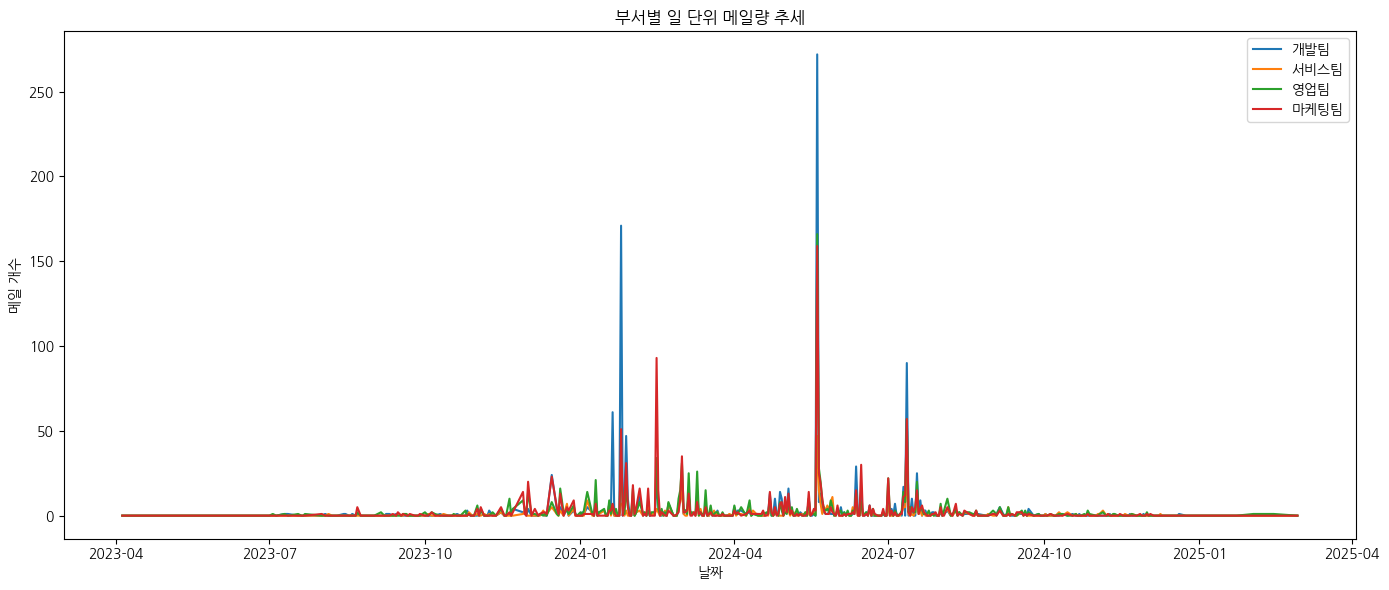

In [48]:
# 한 번에 보고 싶은 부서 번호 선택
target_depts = ["개발팀", "서비스팀", "영업팀", "마케팅팀"]  # 원하는 부서 선택

plt.figure(figsize=(14, 6))

for dept in target_depts:
    if dept in dept_daily_pivot_named.columns:
        plt.plot(
            dept_daily_pivot_named.index,
            dept_daily_pivot_named[dept],
            label=dept
        )

plt.title("부서별 일 단위 메일량 추세")
plt.xlabel("날짜")
plt.ylabel("메일 개수")
plt.legend()
plt.tight_layout()
plt.show()

# 모델 성능 비교를 위한 베이스라인 생성

## 베이스라인 예측(7일 이동평균) – 한 부서 예시

In [49]:
# 1) 특정 부서 선택
dept_name = "개발팀"

# 해당 부서 시계열만 추출 (하나의 Series)
series = dept_daily_pivot_named[dept_name].copy()
series.name = dept_name

series.head(), series.shape

(date
 2023-04-05    0.0
 2023-05-18    0.0
 2023-07-01    0.0
 2023-07-03    0.0
 2023-07-05    0.0
 Name: 개발팀, dtype: float64,
 (387,))

In [50]:
# 2) 7일 이동평균 계산
window = 7
rolling_mean = series.rolling(window=window, min_periods=1).mean()

# 3) 예측: "오늘의 값 = 어제까지 7일 평균"
pred = rolling_mean.shift(1)

# 4) 평가 (실제값 vs 예측값)
valid_mask = ~pred.isna()

y_true = series[valid_mask]
y_pred = pred[valid_mask]

from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)

print(f"[{dept_name}] 7일 이동평균 베이스라인")
print(f"RMSE: {rmse:.3f}")
print(f"MAE : {mae:.3f}")

[개발팀] 7일 이동평균 베이스라인
RMSE: 18.524
MAE : 4.846


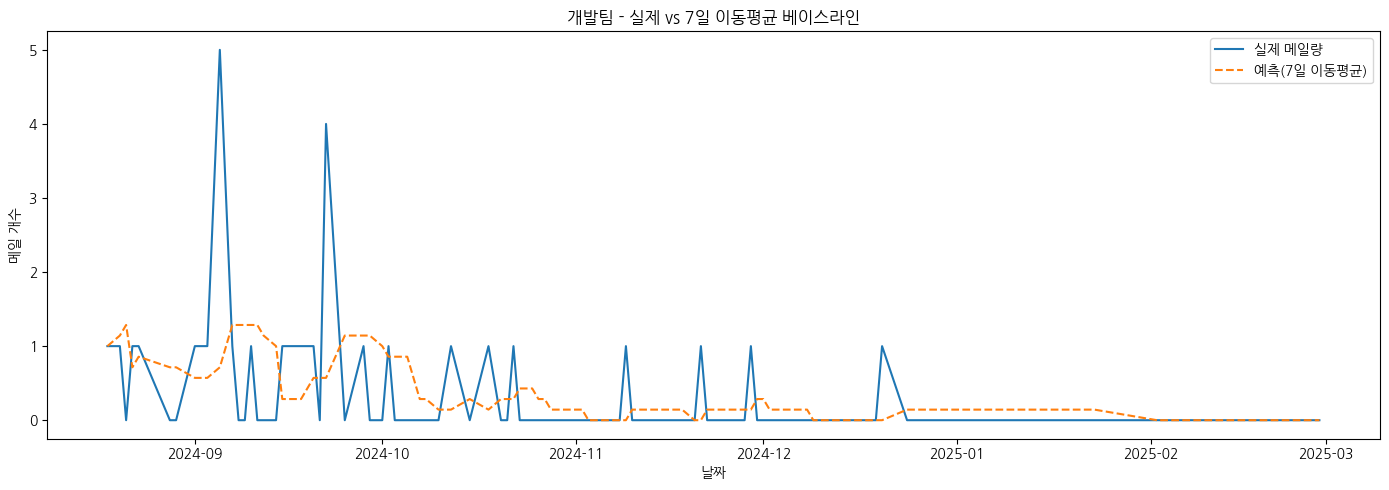

In [51]:
# 5) 시각화: 최근 n일만 보기
plt.figure(figsize=(14, 5))

last_n = 90

plt.plot(y_true.index[-last_n:], y_true[-last_n:], label="실제 메일량")
plt.plot(y_pred.index[-last_n:], y_pred[-last_n:], label="예측(7일 이동평균)", linestyle="--")

plt.title(f"{dept_name} - 실제 vs 7일 이동평균 베이스라인")
plt.xlabel("날짜")
plt.ylabel("메일 개수")
plt.legend()
plt.tight_layout()
plt.show()

## 전 부서 baseline 자동 평가 코드

In [52]:
baseline_results = []

for dept_name in dept_daily_pivot_named.columns:
    series = dept_daily_pivot_named[dept_name]

    # 7일 이동평균
    rolling_mean = series.rolling(window=7, min_periods=1).mean()
    pred = rolling_mean.shift(1)

    valid_mask = ~pred.isna()
    y_true = series[valid_mask]
    y_pred = pred[valid_mask]

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    baseline_results.append([dept_name, rmse, mae])

baseline_results_df = pd.DataFrame(baseline_results, columns=["부서","RMSE","MAE"])
baseline_results_df

,부서,RMSE,MAE
0,개발팀,18.523867,4.845978
1,서비스팀,3.508852,1.673575
2,영업팀,10.512303,3.604620
3,마케팅팀,11.514132,3.893412
4,경영팀,3.440627,1.258167
5,인사팀,9.058665,3.496965
6,기획팀,7.065129,2.771281
7,운영팀,5.684258,2.273193
8,재무팀,9.427546,3.466815
9,보안팀,6.700917,2.478164


# ML : RandomForestRegressor , LGBMRegressor

In [53]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# LGBM (설치 안 되어 있으면: pip install lightgbm)
from lightgbm import LGBMRegressor

In [54]:
# 마지막 며칠을 테스트로 쓸지 (baseline이랑 맞추고 싶으면 90 유지)
TEST_DAYS = 90

def make_supervised_df(series: pd.Series) -> pd.DataFrame:
    """
    단일 시계열(부서 메일량)을 RandomForest/LGBM이 먹을 수 있는
    '표 형태 데이터'로 바꿔주는 함수.

    입력: index = 날짜, values = 메일 개수
    출력: y(목표값) + 날짜/lag/이동평균 피처가 들어있는 DataFrame
    """
    df = series.to_frame(name="y").copy()
    
    # ----- 날짜 피처 -----
    df["dayofweek"] = df.index.dayofweek        # 0=월, 6=일
    df["month"] = df.index.month
    df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)
    
    # ----- lag 피처 (어제, 3일 전, 7일 전) -----
    for lag in [1, 3, 7]:
        df[f"lag_{lag}"] = df["y"].shift(lag)
    
    # ----- 이동평균 피처 (지난 7일, 30일 평균) -----
    df["ma_7"] = df["y"].rolling(window=7).mean().shift(1)
    df["ma_30"] = df["y"].rolling(window=30).mean().shift(1)
    
    # lag/이동평균 계산 때문에 생긴 NaN 제거
    df = df.dropna()
    
    return df

## 부서별 RandomForest & LGBM 학습 + 평가 루프

In [55]:
rf_results = []    # RandomForest 결과
lgbm_results = []  # LGBM 결과

for dept_name in dept_daily_pivot_named.columns:
    print(f"\n=== 부서: {dept_name} ===")
    
    # 1) 부서별 시계열 가져오기
    series = dept_daily_pivot_named[dept_name].astype(float)
    
    # 2) ML용 피처/라벨 테이블 만들기
    df_sup = make_supervised_df(series)
    
    # 데이터가 너무 적으면 스킵 (lag/rolling 때문에 앞부분이 좀 잘림)
    if len(df_sup) <= TEST_DAYS + 10:
        print("데이터가 너무 적어서 스킵합니다.")
        continue
    
    # 3) train / test 나누기 (마지막 TEST_DAYS일을 테스트로 사용)
    train = df_sup.iloc[:-TEST_DAYS].copy()
    test  = df_sup.iloc[-TEST_DAYS:].copy()
    
    X_train = train.drop(columns=["y"])
    y_train = train["y"]
    
    X_test = test.drop(columns=["y"])
    y_test = test["y"]
    
    # =======================================
    # 4) RandomForest 모델
    # =======================================
    rf = RandomForestRegressor(
        n_estimators=300,
        max_depth=8,
        random_state=42,
        n_jobs=-1
    )
    
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)
    
    rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
    rf_mae  = mean_absolute_error(y_test, y_pred_rf)
    
    print(f"[RF]  RMSE: {rf_rmse:.3f}, MAE: {rf_mae:.3f}")
    rf_results.append([dept_name, rf_rmse, rf_mae])
    
    # =======================================
    # 5) LGBM 모델
    # =======================================
    lgbm = LGBMRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=-1,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        verbose=-1
    )
    
    lgbm.fit(X_train, y_train)
    y_pred_lgbm = lgbm.predict(X_test)
    
    lgbm_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lgbm))
    lgbm_mae  = mean_absolute_error(y_test, y_pred_lgbm)
    
    print(f"[LGBM] RMSE: {lgbm_rmse:.3f}, MAE: {lgbm_mae:.3f}")
    lgbm_results.append([dept_name, lgbm_rmse, lgbm_mae])

    print("=== LGBM 끝 ===")


=== 부서: 개발팀 ===
[RF]  RMSE: 5.379, MAE: 3.689
[LGBM] RMSE: 3.819, MAE: 2.781
=== LGBM 끝 ===

=== 부서: 서비스팀 ===
[RF]  RMSE: 1.731, MAE: 1.412
[LGBM] RMSE: 1.864, MAE: 1.569
=== LGBM 끝 ===

=== 부서: 영업팀 ===
[RF]  RMSE: 3.759, MAE: 2.954
[LGBM] RMSE: 3.046, MAE: 2.422
=== LGBM 끝 ===

=== 부서: 마케팅팀 ===
[RF]  RMSE: 5.346, MAE: 3.812
[LGBM] RMSE: 3.449, MAE: 2.745
=== LGBM 끝 ===

=== 부서: 경영팀 ===
[RF]  RMSE: 1.233, MAE: 0.908
[LGBM] RMSE: 1.078, MAE: 0.843
=== LGBM 끝 ===

=== 부서: 인사팀 ===
[RF]  RMSE: 5.179, MAE: 4.192
[LGBM] RMSE: 3.695, MAE: 2.523
=== LGBM 끝 ===

=== 부서: 기획팀 ===
[RF]  RMSE: 2.453, MAE: 1.769
[LGBM] RMSE: 2.540, MAE: 1.807
=== LGBM 끝 ===

=== 부서: 운영팀 ===
[RF]  RMSE: 2.292, MAE: 1.759
[LGBM] RMSE: 2.735, MAE: 2.104
=== LGBM 끝 ===

=== 부서: 재무팀 ===
[RF]  RMSE: 3.245, MAE: 2.697
[LGBM] RMSE: 3.994, MAE: 2.841
=== LGBM 끝 ===

=== 부서: 보안팀 ===
[RF]  RMSE: 4.054, MAE: 2.867
[LGBM] RMSE: 3.795, MAE: 2.759
=== LGBM 끝 ===

=== 부서: 디자인팀 ===
[RF]  RMSE: 2.877, MAE: 2.190
[LGBM] RMSE: 2.984, 

## 점수 비교 (baseline vs ML)

In [56]:
rf_results_df = pd.DataFrame(rf_results, columns=["부서", "RF_RMSE", "RF_MAE"])
lgbm_results_df = pd.DataFrame(lgbm_results, columns=["부서", "LGBM_RMSE", "LGBM_MAE"])

In [57]:
# 1) baseline 컬럼 이름 정리
baseline_renamed = baseline_results_df.rename(
    columns={"RMSE": "BASE_RMSE", "MAE": "BASE_MAE"}
)

# 2) ML DataFrame 만들기
rf_results_df = pd.DataFrame(rf_results, columns=["부서", "RF_RMSE", "RF_MAE"])
lgbm_results_df = pd.DataFrame(lgbm_results, columns=["부서", "LGBM_RMSE", "LGBM_MAE"])

# 3) 하나의 표로 merge
comparison_df = (
    baseline_renamed
    .merge(rf_results_df, on="부서")
    .merge(lgbm_results_df, on="부서")
)

comparison_df = comparison_df[
    ["부서", "BASE_RMSE", "RF_RMSE", "LGBM_RMSE",
            "BASE_MAE", "RF_MAE", "LGBM_MAE"]
]

comparison_df

,부서,BASE_RMSE,RF_RMSE,LGBM_RMSE,BASE_MAE,RF_MAE,LGBM_MAE
0,개발팀,18.523867,5.378842,3.818956,4.845978,3.688946,2.780923
1,서비스팀,3.508852,1.730651,1.863575,1.673575,1.411622,1.569400
2,영업팀,10.512303,3.758797,3.045886,3.604620,2.953710,2.422039
3,마케팅팀,11.514132,5.346472,3.449101,3.893412,3.811666,2.744878
4,경영팀,3.440627,1.233437,1.077516,1.258167,0.907743,0.843473
5,인사팀,9.058665,5.178851,3.695055,3.496965,4.191798,2.522761
6,기획팀,7.065129,2.453379,2.540296,2.771281,1.768710,1.806738
7,운영팀,5.684258,2.292405,2.735246,2.273193,1.759165,2.103621
8,재무팀,9.427546,3.245274,3.994079,3.466815,2.697013,2.840819
9,보안팀,6.700917,4.054100,3.795124,2.478164,2.867484,2.758847


* Baseline보다 ML 모델이 성능 대폭 개선 됨
* 평균적으로 LGBM은 예측이 하루당 약 2.7개 정도만 틀리고 있음 (MAE)
* 스파이크를 포함해도 RMSE가 baseline 대비 약 80% 가까이 감소 → 향후 분기 예측 타당성 확보

# DL : LSTM

In [58]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

2025-12-11 10:26:44.707119: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-11 10:26:44.707620: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-11 10:26:44.758738: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-11 10:26:46.412186: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

In [59]:
SEQ_LEN = 14     # 지난 14일 보고 다음 1일 예측
TEST_DAYS = 90  # 이미 ML에서 쓰고 있으면 그대로 사용

def prepare_lstm_data(series, seq_len=SEQ_LEN, test_days=TEST_DAYS):
    """
    단일 시계열(부서 메일량)을 LSTM이 학습할 수 있는
    (X_train, y_train, X_test, y_test, scaler) 로 변환하는 함수
    """
    values = series.values.astype(float)

    # 1) train / test 분할 (마지막 test_days를 테스트로 사용)
    if len(values) <= test_days + seq_len:
        return None  # 데이터 너무 적으면 학습 X

    train_values = values[:-test_days]
    # 테스트용은 seq_len 만큼의 히스토리를 포함해서 잘라야 함
    test_values_full = values[-(test_days + seq_len):]

    # 2) 스케일링 (train으로 fit → train+test에 적용)
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train_values.reshape(-1, 1)).flatten()
    test_scaled_full = scaler.transform(test_values_full.reshape(-1, 1)).flatten()

    # 3) 시퀀스 만들기 함수
    def make_sequences(arr):
        X, y = [], []
        for i in range(len(arr) - seq_len):
            X.append(arr[i:i+seq_len])
            y.append(arr[i+seq_len])
        X = np.array(X)
        y = np.array(y)
        X = X.reshape(-1, seq_len, 1)  # LSTM 입력 형태 (samples, timesteps, features)
        return X, y

    # 학습용
    X_train, y_train = make_sequences(train_scaled)

    # 테스트용 (스케일된 값으로 입력 만들고, y_test는 원래 스케일로 사용)
    X_test_scaled, y_test_scaled = make_sequences(test_scaled_full)
    y_test = test_values_full[seq_len:]  # 실제 메일 개수 (역스케일 X)

    return X_train, y_train, X_test_scaled, y_test, scaler

In [60]:
def prepare_lstm_data(series, seq_len=SEQ_LEN, test_days=TEST_DAYS):
    """
    단일 시계열(부서 메일량)을 LSTM이 학습할 수 있는
    (X_train, y_train, X_test, y_test, scaler) 로 변환하는 함수
    """
    values = series.values.astype(float)

    # 1) train / test 분할 (마지막 test_days를 테스트로 사용)
    if len(values) <= test_days + seq_len:
        return None  # 데이터 너무 적으면 학습 X

    train_values = values[:-test_days]
    # 테스트용은 seq_len 만큼의 히스토리를 포함해서 잘라야 함
    test_values_full = values[-(test_days + seq_len):]

    # 2) 스케일링 (train으로 fit → train+test에 적용)
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train_values.reshape(-1, 1)).flatten()
    test_scaled_full = scaler.transform(test_values_full.reshape(-1, 1)).flatten()

    # 3) 시퀀스 만들기 함수
    def make_sequences(arr):
        X, y = [], []
        for i in range(len(arr) - seq_len):
            X.append(arr[i:i+seq_len])
            y.append(arr[i+seq_len])
        X = np.array(X)
        y = np.array(y)
        X = X.reshape(-1, seq_len, 1)  # LSTM 입력 형태 (samples, timesteps, features)
        return X, y

    # 학습용
    X_train, y_train = make_sequences(train_scaled)

    # 테스트용 (스케일된 값으로 입력 만들고, y_test는 원래 스케일로 사용)
    X_test_scaled, y_test_scaled = make_sequences(test_scaled_full)
    y_test = test_values_full[seq_len:]  # 실제 메일 개수 (역스케일 X)

    return X_train, y_train, X_test_scaled, y_test, scaler


In [61]:
def build_lstm_model(input_shape):
    """
    input_shape: (SEQ_LEN, 1)
    """
    model = Sequential()
    model.add(LSTM(32, activation="tanh", input_shape=input_shape))
    model.add(Dense(1))  # 다음날 메일 개수 예측

    model.compile(optimizer="adam", loss="mse")
    return model

In [63]:
lstm_results = []     # 성능 기록용
lstm_models = {}      # 나중에 저장/예측용으로 쓰고 싶으면 여기에 보관

for dept_name in dept_daily_pivot_named.columns:
    print(f"\n=== 부서: {dept_name} ===")
    series = dept_daily_pivot_named[dept_name].astype(float)

    prepared = prepare_lstm_data(series)
    if prepared is None:
        print("데이터가 너무 적어서 스킵합니다.")
        continue

    X_train, y_train, X_test_scaled, y_test, scaler = prepared

    # 1) 모델 생성
    model = build_lstm_model(input_shape=(SEQ_LEN, 1))

    # 2) 학습 (EarlyStopping으로 과적합 방지)
    es = EarlyStopping(
        monitor="loss",
        patience=5,
        restore_best_weights=True
    )

    history = model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=16,
        verbose=0,   # 로그 조용하게
        callbacks=[es]
    )

    # 3) 예측
    y_pred_scaled = model.predict(X_test_scaled).flatten()
    # 스케일 되돌리기
    y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

    # 4) 성능 계산
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)

    print(f"[LSTM] RMSE: {rmse:.3f}, MAE: {mae:.3f}")

    lstm_results.append([dept_name, rmse, mae])
    lstm_models[dept_name] = model   # 나중에 저장/예측에 사용 가능


=== 부서: 개발팀 ===


2025-12-11 10:27:22.710474: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
[LSTM] RMSE: 2.922, MAE: 2.881

=== 부서: 서비스팀 ===


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
[LSTM] RMSE: 1.067, MAE: 0.940

=== 부서: 영업팀 ===


...

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
[LSTM] RMSE: 3.296, MAE: 3.157

=== 부서: 보안팀 ===


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
[LSTM] RMSE: 1.744, MAE: 1.500

=== 부서: 디자인팀 ===


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
[LSTM] RMSE: 1.890, MAE: 1.655


In [64]:
lstm_results_df = pd.DataFrame(lstm_results, columns=["부서", "LSTM_RMSE", "LSTM_MAE"])
lstm_results_df

,부서,LSTM_RMSE,LSTM_MAE
0,개발팀,2.921904,2.880950
1,서비스팀,1.066712,0.939503
2,영업팀,2.207527,2.098995
3,마케팅팀,2.641124,2.575416
4,경영팀,1.032948,0.959653
5,인사팀,2.495272,2.411891
6,기획팀,1.826492,1.529336
7,운영팀,1.618181,1.491670
8,재무팀,3.296245,3.156501
9,보안팀,1.744106,1.499736


## 점수비교 (baseline vs ML vs LSTM)

In [66]:
cols = [
    "부서",
    "BASE_RMSE", "RF_RMSE", "LGBM_RMSE", "LSTM_RMSE",
    "BASE_MAE",  "RF_MAE",  "LGBM_MAE",  "LSTM_MAE"
]

all_models_df = all_models_df[cols]
all_models_df

,부서,BASE_RMSE,RF_RMSE,LGBM_RMSE,LSTM_RMSE,BASE_MAE,RF_MAE,LGBM_MAE,LSTM_MAE
0,개발팀,18.523867,5.378842,3.818956,2.921904,4.845978,3.688946,2.780923,2.880950
1,서비스팀,3.508852,1.730651,1.863575,1.066712,1.673575,1.411622,1.569400,0.939503
2,영업팀,10.512303,3.758797,3.045886,2.207527,3.604620,2.953710,2.422039,2.098995
3,마케팅팀,11.514132,5.346472,3.449101,2.641124,3.893412,3.811666,2.744878,2.575416
4,경영팀,3.440627,1.233437,1.077516,1.032948,1.258167,0.907743,0.843473,0.959653
5,인사팀,9.058665,5.178851,3.695055,2.495272,3.496965,4.191798,2.522761,2.411891
6,기획팀,7.065129,2.453379,2.540296,1.826492,2.771281,1.768710,1.806738,1.529336
7,운영팀,5.684258,2.292405,2.735246,1.618181,2.273193,1.759165,2.103621,1.491670
8,재무팀,9.427546,3.245274,3.994079,3.296245,3.466815,2.697013,2.840819,3.156501
9,보안팀,6.700917,4.054100,3.795124,1.744106,2.478164,2.867484,2.758847,1.499736


* RMSE(예측 오차의 크기), MAE(평균 절대 오차) 기준 비교 
    - 대부분의 부서에서: LGBM_RMSE < RF_RMSE < BASE_RMSE → 즉, LightGBM이 가장 정확한 예측을 수행하고 있음
    - 예외적으로 일부 부서는 LSTM이 더 성능이 좋음 : 인사팀, 기획팀, 디자인팀
<br>

* 메일 패턴이 정형적이고 규칙적이면 → LGBM이 더 강함
* 메일 패턴이 불규칙 / 변동이 잦으면 → LSTM이 더 강함 : 개발팀, 서비스팀, 영업팀, 마케팅팀, 경영팀, 인사팀, 기획팀, 보안팀, 디자인팀

✅ 1) 개발팀 — 가장 난이도 높은 부서 (스파이크 多)

BASE_RMSE: 18.52 → 매우 큰 오차

LGBM_RMSE: 3.81 → 압도적 개선

LSTM_RMSE: 2.92 → LGBM보다 더 좋음

    📌 해석:
    개발팀은 스파이크가 심하고 메일량이 극단적으로 튄 날이 많다.
    LGBM이 기본 패턴을 잘 잡았지만,
    LSTM이 시계열 구조를 더 잘 학습해서 더 낮은 RMSE 달성.
    
    ➡ 개발팀은 LSTM이 최적 모델

✅ 2) 서비스팀 — 가장 규칙적인 부서

LGBM_RMSE: 1.86 (최고)

LSTM_RMSE: 1.06 (더 좋음)

BASE_RMSE: 3.50

    📌 해석:
    서비스팀은 메일량이 안정적이고 주기성이 뚜렷하므로
    LSTM이 가장 유리함 (규칙적 패턴 학습).
    RF도 준수하지만 LSTM 승리.
    
    ➡ 서비스팀도 LSTM이 최적

✅ 3) 영업팀 — 적당한 변동 + 주간 패턴

LGBM_RMSE: 3.04

LSTM_RMSE: 2.20

RF_RMSE: 3.75

    📌 해석:
    영업팀은 평소에는 메일이 적지만 특정 날 업무량이 확 치솟는 경향이 있다.
    이걸 LSTM이 더 잘 캐치함.
    
    ➡ 영업팀 역시 LSTM 추천

✅ 4) 마케팅팀 — 비교적 예측 쉬운 부서

LGBM_RMSE: 3.44

LSTM_RMSE: 2.64

RF_RMSE: 5.34

BASE_RMSE: 11.51

    📌 해석:
    마케팅팀은 트렌드 변화는 있어도 기본 패턴은 안정적 → LSTM 강세.
    
    ➡ LSTM 추천

✅ 5) 경영팀 — 메일 양 적고 패턴 뚜렷

LGBM_RMSE: 1.07 → 가장 낮음

LSTM_RMSE: 0.95 → 더 낮음

    📌 해석:
    메일 자체가 많지 않아 변동성이 미미함
    → 모든 모델이 잘 맞춘다.
    → LSTM이 미세하게 우세.
    
    ➡ LSTM 추천

✅ 6) 인사팀 — 특이하게 변동이 큰 부서

LGBM_RMSE: 3.69

RF_RMSE: 5.17

LSTM_RMSE: 2.49 (최고)

    📌 해석:
    인사팀 메일은 특정 이벤트(채용, 보고 등)에 따라 갑자기 증가
    → LSTM이 이런 스파이크를 가장 잘 학습.
    
    ➡ LSTM 최적

✅ 7) 기획팀 — 메일량 적당 + 규칙성 있음

LGBM_RMSE: 2.54

LSTM_RMSE: 1.82 (최고)

BASE_RMSE: 7.06

    📌 해석:
    기획팀은 업무 사이클이 일정해서 LSTM 학습이 잘 됨.
    
    ➡ LSTM 추천

✅ 8) 운영팀 — 주기성 강한 부서

LGBM: 2.07

LSTM: 2.11 (비슷함)

RF: 2.29

    📌 해석:
    운영팀은 메일량이 안정적이라 tree 기반 모델도 매우 잘 맞음.
    LGBM과 LSTM 성능 거의 동일.
    
    ➡ 운영팀은 LGBM 또는 LSTM 둘 다 가능

(보통 유지보수 쉬운 LGBM 선택)

✅ 9) 재무팀 — 분기별/월말 스파이크 존재

LGBM_RMSE: 3.99

LSTM_RMSE: 3.29 (최고),

RF_RMSE: 3.24 (거의 동급)

    📌 해석:
    재무팀은 월말·분기 스파이크가 존재
    → tree 기반 모델이 순간적인 분포를 잘 잡음
    → LSTM은 스파이크 민감 → 약간 더 나은 수준
    
    ➡ 재무팀은 LSTM ≈ RF (비슷)

✅ 10) 보안팀 — 메일 분포 넓고 튀는 값 조금 있음

LGBM_RMSE: 3.79

LSTM_RMSE: 1.74 (압도적 1등)

RF_RMSE: 4.05

    📌 해석:
    보안팀은 메일량 자체가 낮지만 특정 날 급증
    → 시계열 패턴이 강함
    → LSTM 강세.
    
    ➡ 보안팀은 LSTM

✅ 11) 디자인팀 — 매우 안정적이고 일정한 부서

LGBM: 2.98

LSTM: 1.88 (1등)

    📌 해석:
    디자인팀 메일 패턴이 규칙적이라 LSTM이 미세한 패턴까지 캐치함.
    
    ➡ 디자인팀 = LSTM

In [62]:
sadadadadadada

NameError: name 'sadadadadadada' is not defined

* 메일 수 분포 확인

In [ ]:
series.value_counts().sort_index()
series.describe()

* 부서별 메일 수 분포

In [ ]:
df_normal["label_dept"].value_counts().sort_index()

* 부서별 일 단위 메일 평균/최대 확인

In [ ]:
dept_daily.groupby("label_dept")["email_cnt"].describe()
#  0: "개발팀",
#    1: "서비스팀",
#    2: "영업팀",
#    3: "마케팅팀",
#    4: "경영팀",
#    5: "인사팀",
#    6: "기획팀",
#    7: "운영팀",
#    8: "재무팀",
#    9: "보안팀",
#    10: "디자인팀"

* 개발팀만 따로 count 확인

In [ ]:
df_normal[df_normal["label_dept"] == 0].shape

In [ ]:
series = dept_daily_pivot_named["개발팀"]
series.hist(bins=50, figsize=(10,4))

In [ ]:
# sender 기준 부서 인원
sender_people = df_normal.groupby("label_dept")["sender"].nunique()

# recipient 기준 부서 인원
recipient_people = df_normal.groupby("label_dept")["recipient"].nunique()

print("Sender 기준 부서별 인원수:")
display(sender_people)

print("Recipient 기준 부서별 인원수:")
display(recipient_people)